# GPU check

In [6]:
#Check GPU status
!nvidia-smi
#Install Hugging Face Transformers library
!pip install transformers

Tue Apr 21 10:37:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000001:00:00.0 Off |                  Off |
| N/A   69C    P0             69W /   70W |   14289MiB /  16384MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Problem 2
**Dataset:** AG News (Subset) - 120k labeled training samples, 7.6k unlabeled test samples.
**Classes:** 0: World, 1: Sports, 2: Business, 3: Sci/Tech (shifted from 1-4 for PyTorch compatibility).

## Imports

In [10]:
import pandas as pd
import numpy as np
import torch
import json
import os
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertConfig, BertForSequenceClassification
from torch.optim import AdamW  # <-- Changed this line
from sklearn.model_selection import train_test_split
#from tqdm.auto import tqdm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import time
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, accuracy_score, confusion_matrix
import torch.nn.functional as F

# Matplotlib configuration
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})

# Set device to gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [55]:
import gc

gc.collect()
# Empty the PyTorch CUDA cache
torch.cuda.empty_cache()

print("Memory cleared!")

Memory cleared!


## Definitions

### Dataset class
DataLoader class to handle batching and shuffling of the dataset.

In [8]:
class NewsDataset(Dataset):
    """PyTorch Dataset for the AG News Data. Defined as a child class of torch.utils.data.Dataset, 
        so we can directly call the tokenizer in __getitem__."""
    
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        # Labels for training, test data will have None
        label = self.labels[item] if self.labels is not None else -1
        
        # Call the tokenizer directly, it is inherited from Dataset base class
        encoding = self.tokenizer(
            text,
            add_special_tokens=True, #BERT requires special tokens (CLS, SEP etc.)
            max_length=self.max_len,
            padding='max_length',
            truncation=True, # if text is longer than max_len, cut it
            return_attention_mask=True, # BERT needs attention masks to differentiate between real tokens and padding
            return_tensors='pt', # Return PyTorch tensors
        )
        
        output = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }
        
        if self.labels is not None:
            output['labels'] = torch.tensor(label, dtype=torch.long)
            
        return output

### Training function

In [9]:
def train_and_evaluate(model, train_loader, val_loader, optimizer, epochs=3, save_prefix="model_checkpoint"):
    """Trains the model, evaluates, and saves checkpoints after each epoch.
     - model: The BERT model to train
     - train_loader: DataLoader for training data
     - val_loader: DataLoader for validation data
     - optimizer: Optimizer for training
     - epochs: Number of epochs to train
     - save_prefix: Prefix for saving model checkpoints and history
    """

    # Loss and accuracy are tracked after each epoch into a history dictionary
    # Saved into json after each epoch
    history = {'train_loss': [], 'val_accuracy': []}
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 25)
        
        # --- TRAINING ---
        model.train() # Set model to training mode
        total_train_loss = 0
        total_batches = len(train_loader) # Length of data loader is the number of batches
        
        for step, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device) # Sending input_ids to the device (GPU or CPU)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            model.zero_grad() # Resetting gradients before each step
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels) # Forward pass with labels to get loss
            loss = outputs.loss
            total_train_loss += loss.item() # Accumulate loss for averaging. It is averaged over all batches at the end of the epoch.
            
            loss.backward() # Backpropagation to compute gradients
            optimizer.step() # Update model parameters
            
            # Print update every 100 batches
            if step % 100 == 0 and step > 0:
                print(f"  Training Batch {step}/{total_batches} | Current Loss: {loss.item():.4f}")
                
        avg_train_loss = total_train_loss / total_batches # Average loss over all batches
        history['train_loss'].append(avg_train_loss) # Save average training loss for this epoch
        
        # --- VALIDATION ---
        print("\n  Running Validation...")
        model.eval() # Set model to evaluation mode
        correct_predictions = 0
        total_predictions = 0
        
        with torch.no_grad():
            for step, batch in enumerate(val_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(input_ids, attention_mask=attention_mask)
                # outputs.logits contains the raw scores for each class for each sample from the batch 
                # i.e. shape of outputs.logits is (batch_size, num_classes)
                # torch.max returns the maximum value and the index of the maximum value for each sample
                _, preds = torch.max(outputs.logits, dim=1) # Raw score values are discarded, we only care about the predicted class index (preds)
                
                correct_predictions += torch.sum(preds == labels) # Count how many predictions were correct in this batch
                total_predictions += labels.shape[0]
                
        val_acc = correct_predictions.double() / total_predictions
        history['val_accuracy'].append(val_acc.item())
        
        print(f"  >> Epoch {epoch + 1} Summary: Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_acc:.4f}")
        
        # --- SAVING CHECKPOINT ---
        # Save model state dict after each epoch with epoch number in the filename
        model_save_path = f"{save_prefix}_epoch_{epoch+1}.pt"
        torch.save(model.state_dict(), model_save_path)
        
        # Save training history metrics into a json file after each epoch
        history_save_path = f"{save_prefix}_history.json"
        with open(history_save_path, "w") as f:
            json.dump(history, f)
            
        print(f"  >> Checkpoint saved: {model_save_path}")
        
    return history

In [5]:
def train_and_evaluate_tracked(model, train_loader, val_loader, optimizer, epochs=3, save_prefix="bert_tracked"):
    """Trains the model with granular time, loss, and advanced sklearn metrics.
     - model: The BERT model to train
     - train_loader: DataLoader for training data
     - val_loader: DataLoader for validation data
     - optimizer: Optimizer for training
     - epochs: Number of training epochs
     - save_prefix: Prefix for saving model checkpoints and history
    """
    
    history = {
        'train_loss_epoch': [],
        'val_loss_epoch': [],
        'val_accuracy_epoch': [],
        'val_f1_epoch': [],
        'batch_loss': [],
        'batch_steps': [],
        'batch_times': [],  
        'val_times': [],    
        'val_steps': []     
    }
    
    global_step = 0
    start_time = time.time()
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 35)
        
        # --- TRAINING ---
        model.train()
        total_train_loss = 0
        total_batches = len(train_loader)
        epoch_start_time = time.time()
        
        for step, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            model.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_train_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
            global_step += 1
            
            # Record metrics every 100 steps
            if step % 100 == 0 and step > 0:
                current_time = time.time() - start_time
                current_loss = loss.item()
                print(f"  Batch {step}/{total_batches} | Loss: {current_loss:.4f} | Time: {current_time:.1f}s")
                
                history['batch_loss'].append(current_loss)
                history['batch_steps'].append(global_step)
                history['batch_times'].append(current_time)
                
        avg_train_loss = total_train_loss / total_batches
        history['train_loss_epoch'].append(avg_train_loss)
        
        epoch_duration = time.time() - epoch_start_time
        batches_per_sec = total_batches / epoch_duration
        print(f"\n  >> Epoch {epoch + 1} Speed: {epoch_duration:.1f}s ({batches_per_sec:.2f} batches/sec)")
        
        # --- VALIDATION ---
        print("  Running Validation...")
        model.eval()
        total_val_loss = 0
        
        # Lists to store all predictions and true labels for scikit-learn
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for step, batch in enumerate(val_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                # Pass labels to get validation loss
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                total_val_loss += loss.item()
                
                _, preds = torch.max(outputs.logits, dim=1)
                
                # Move tensors to CPU and convert to numpy for sklearn
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        # --- SCIKIT-LEARN METRICS ---
        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        
        # 'weighted' accounts for label imbalance (though AG News is perfectly balanced)
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        val_precision = precision_score(all_labels, all_preds, average='weighted')
        val_recall = recall_score(all_labels, all_preds, average='weighted')
        
        current_time = time.time() - start_time
        history['val_loss_epoch'].append(avg_val_loss)
        history['val_accuracy_epoch'].append(val_acc)
        history['val_f1_epoch'].append(val_f1)
        history['val_times'].append(current_time)
        history['val_steps'].append(global_step)
        
        print(f"  >> Epoch {epoch + 1} Summary:")
        print(f"     Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"     Accuracy:   {val_acc:.4f} | F1-Score: {val_f1:.4f}")
        
        # Print a detailed classification report on the final epoch
        if epoch == epochs - 1:
            print("\n  >> Final Epoch Classification Report:")
            # Target names map to our 0-3 indices (World, Sports, Business, Sci/Tech)
            print(classification_report(all_labels, all_preds, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))
        
        # --- SAVING CHECKPOINT ---
        model_save_path = f"{save_prefix}_epoch_{epoch+1}.pt"
        torch.save(model.state_dict(), model_save_path)
        
        history_save_path = f"{save_prefix}_history.json"
        with open(history_save_path, "w") as f:
            json.dump(history, f)
            
    return history

### Evaluation functions

In [64]:
def save_json(data, path):
    """Save a dictionary to JSON with basic numpy/tensor conversion."""
    def _convert(value):
        if isinstance(value, np.ndarray):
            return value.tolist()
        if isinstance(value, torch.Tensor):
            return value.detach().cpu().numpy().tolist()
        if isinstance(value, (np.integer, np.floating)):
            return value.item()
        if isinstance(value, dict):
            return {k: _convert(v) for k, v in value.items()}
        if isinstance(value, list):
            return [_convert(v) for v in value]
        return value

    folder = os.path.dirname(path)
    if folder:
        os.makedirs(folder, exist_ok=True)

    with open(path, 'w', encoding='utf-8') as f:
        json.dump(_convert(data), f, indent=2)


def save_validation_run(run_object, run_path='objects/eval/validation_run.npz'):
    """Save validation run object as compressed NumPy file."""
    folder = os.path.dirname(run_path)
    if folder:
        os.makedirs(folder, exist_ok=True)
    np.savez_compressed(run_path, **run_object)


def load_validation_run(run_path='objects/eval/validation_run.npz'):
    """Load validation run object from compressed NumPy file."""
    raw = np.load(run_path, allow_pickle=True)
    return {k: raw[k] for k in raw.files}


def plot_metrics(history, title_suffix=''):
    """Plots training loss and validation accuracy over epochs."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, ax1 = plt.subplots()
    ax1.grid(True, linestyle='--', alpha=0.6)

    color = 'tab:red'
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Training Loss', color=color, fontweight='bold')
    ax1.plot(epochs, history['train_loss'], color=color, marker='o', linewidth=2, label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Validation Accuracy', color=color, fontweight='bold')
    ax2.plot(epochs, history['val_accuracy'], color=color, marker='s', linewidth=2, label='Val Accuracy')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Training Progress {title_suffix}', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()


def plot_metrics_extended(history, title_prefix=''):
    """Generates a 2x2 grid of scientific plots for detailed training analysis."""
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{title_prefix} Comprehensive Training Metrics', fontsize=16, fontweight='bold', y=1.02)

    for ax in axs.flat:
        ax.grid(True, linestyle='--', alpha=0.6)

    epochs = range(1, len(history['val_accuracy_epoch']) + 1)
    axs[0, 0].plot(epochs, history['val_accuracy_epoch'], marker='s', color='tab:blue', linewidth=2)
    axs[0, 0].set_title('Epoch vs Validation Accuracy', fontweight='bold')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].set_xticks(epochs)

    axs[0, 1].plot(history['batch_steps'], history['batch_loss'], color='tab:red', alpha=0.7)
    axs[0, 1].set_title('Batch Step vs Training Loss', fontweight='bold')
    axs[0, 1].set_xlabel('Global Batch Step')
    axs[0, 1].set_ylabel('Cross-Entropy Loss')

    axs[1, 0].plot(history['batch_times'], history['batch_loss'], color='tab:purple', alpha=0.7)
    axs[1, 0].set_title('Time elapsed vs Training Loss', fontweight='bold')
    axs[1, 0].set_xlabel('Time (Seconds)')
    axs[1, 0].set_ylabel('Cross-Entropy Loss')

    axs[1, 1].plot(history['val_times'], history['val_accuracy_epoch'], marker='o', color='tab:green', linewidth=2)
    axs[1, 1].set_title('Time elapsed vs Validation Accuracy', fontweight='bold')
    axs[1, 1].set_xlabel('Time (Seconds)')
    axs[1, 1].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()


class UniversalEvaluator:
    """Simple evaluator: one cached validation run + reusable metrics/plots/helpers."""

    def __init__(self, model, device, tokenizer=None, class_names=None):
        self.model = model
        self.device = device
        self.tokenizer = tokenizer
        self.class_names = class_names or ['World', 'Sports', 'Business', 'Sci/Tech']

    def run_validation(
        self,
        val_loader,
        run_path='objects/eval/validation_run.npz',
        force_run=False,
        include_input_ids=False,
        include_probabilities=True,
        warmup=True,
        max_batches=None
    ):
        """Load or run validation inference. This is the only heavy output we cache."""
        if (not force_run) and os.path.exists(run_path):
            run_object = load_validation_run(run_path)
            needs_rerun = include_input_ids and ('input_ids' not in run_object)
            if not needs_rerun:
                print(f'Loaded validation run: {run_path}')
                return run_object

        run_object = self._infer_validation(
            val_loader=val_loader,
            include_input_ids=include_input_ids,
            include_probabilities=include_probabilities,
            warmup=warmup,
            max_batches=max_batches,
        )
        save_validation_run(run_object, run_path=run_path)
        print(f'Saved validation run: {run_path}')
        return run_object

    def _infer_validation(
        self,
        val_loader,
        include_input_ids=False,
        include_probabilities=True,
        warmup=True,
        max_batches=None,
    ):
        self.model.eval()

        all_labels, all_preds, all_logits = [], [], []
        all_input_ids, all_probs = [], []

        if warmup:
            dummy_batch = next(iter(val_loader))
            with torch.no_grad():
                _ = self.model(
                    dummy_batch['input_ids'].to(self.device),
                    attention_mask=dummy_batch['attention_mask'].to(self.device),
                )
            if str(self.device).startswith('cuda') and torch.cuda.is_available():
                torch.cuda.synchronize()

        if str(self.device).startswith('cuda') and torch.cuda.is_available():
            torch.cuda.synchronize()
        start_time = time.time()

        with torch.no_grad():
            for i, batch in enumerate(val_loader):
                if max_batches is not None and i >= max_batches:
                    break

                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                probs = F.softmax(logits, dim=1)
                preds = torch.argmax(logits, dim=1)

                all_labels.append(labels.cpu())
                all_preds.append(preds.cpu())
                all_logits.append(logits.cpu())

                if include_input_ids:
                    all_input_ids.append(input_ids.cpu())
                if include_probabilities:
                    all_probs.append(probs.cpu())

        if str(self.device).startswith('cuda') and torch.cuda.is_available():
            torch.cuda.synchronize()
        duration = time.time() - start_time

        labels_tensor = torch.cat(all_labels) if all_labels else torch.empty(0, dtype=torch.long)
        preds_tensor = torch.cat(all_preds) if all_preds else torch.empty(0, dtype=torch.long)
        logits_tensor = torch.cat(all_logits) if all_logits else torch.empty((0, len(self.class_names)), dtype=torch.float32)

        run_object = {
            'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
            'device': str(self.device),
            'num_batches': len(all_labels),
            'num_samples': int(labels_tensor.shape[0]),
            'duration_seconds': float(duration),
            'labels': labels_tensor.numpy(),
            'preds': preds_tensor.numpy(),
            'logits': logits_tensor.numpy(),
        }

        if include_input_ids:
            input_ids_tensor = torch.cat(all_input_ids) if all_input_ids else torch.empty((0, 0), dtype=torch.long)
            run_object['input_ids'] = input_ids_tensor.numpy()
        if include_probabilities:
            probs_tensor = torch.cat(all_probs) if all_probs else torch.empty((0, len(self.class_names)), dtype=torch.float32)
            run_object['probabilities'] = probs_tensor.numpy()

        return run_object

    def metrics(self, run_object):
        labels = run_object['labels']
        preds = run_object['preds']
        return {
            'accuracy': accuracy_score(labels, preds),
            'precision': precision_score(labels, preds, average='weighted'),
            'recall': recall_score(labels, preds, average='weighted'),
            'f1': f1_score(labels, preds, average='weighted'),
        }

    def report(self, run_object):
        return classification_report(run_object['labels'], run_object['preds'], target_names=self.class_names)

    def confusion(self, run_object):
        return confusion_matrix(run_object['labels'], run_object['preds'])

    def speed(self, run_object):
        total = max(run_object['duration_seconds'], 1e-12)
        samples = max(run_object['num_samples'], 1)
        return {
            'total_time_seconds': total,
            'throughput_samples_per_sec': samples / total,
            'latency_ms_per_sample': (total / samples) * 1000.0,
        }

    def print_metrics(self, metrics, title='Validation Metrics'):
        print(f'\n=== {title} ===')
        print(f"Accuracy:  {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall:    {metrics['recall']:.4f}")
        print(f"F1-Score:  {metrics['f1']:.4f}")

    def plot_confusion_matrix(self, cm, ax=None, title='Confusion Matrix'):
        if ax is None:
            _, ax = plt.subplots(figsize=(6, 6))

        cax = ax.matshow(cm, cmap='Blues')
        plt.colorbar(cax, ax=ax)

        threshold = cm.max() / 2.0 if cm.size > 0 else 0.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > threshold else 'black',
                    fontweight='bold'
                )

        ax.set_xticks(np.arange(len(self.class_names)))
        ax.set_yticks(np.arange(len(self.class_names)))
        ax.set_xticklabels(self.class_names)
        ax.set_yticklabels(self.class_names)
        ax.xaxis.set_ticks_position('bottom')
        ax.set_xlabel('Predicted Label', fontweight='bold')
        ax.set_ylabel('True Label', fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.grid(False)

    def profile(self, run_object, model_name='BERT Model', save_json_path=None):
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in self.model.parameters())

        param_size = sum(param.nelement() * param.element_size() for param in self.model.parameters())
        buffer_size = sum(buffer.nelement() * buffer.element_size() for buffer in self.model.buffers())
        size_mb = (param_size + buffer_size) / 1024**2

        speed_info = self.speed(run_object)
        metrics = self.metrics(run_object)

        summary = {
            'model_name': model_name,
            'parameters_total': total_params,
            'parameters_trainable': trainable_params,
            'model_size_mb': size_mb,
            **speed_info,
            **metrics,
        }

        if save_json_path:
            save_json(summary, save_json_path)

        return summary

    def benchmark_hardware(self, val_loader, batches_to_test=100, save_json_path=None):
        """Runs benchmark and optionally saves only a simple JSON summary."""
        devices = ['cpu']
        if torch.cuda.is_available():
            devices.append('cuda')

        original_device = next(self.model.parameters()).device
        summary = {}

        for dev in devices:
            self.model = self.model.to(dev)
            self.model.eval()

            dummy_batch = next(iter(val_loader))
            with torch.no_grad():
                _ = self.model(
                    dummy_batch['input_ids'].to(dev),
                    attention_mask=dummy_batch['attention_mask'].to(dev),
                )
            if dev == 'cuda':
                torch.cuda.synchronize()

            start_time = time.time()
            sample_count = 0

            with torch.no_grad():
                for i, batch in enumerate(val_loader):
                    if i >= batches_to_test:
                        break
                    input_ids = batch['input_ids'].to(dev)
                    attention_mask = batch['attention_mask'].to(dev)
                    _ = self.model(input_ids, attention_mask=attention_mask)
                    sample_count += input_ids.size(0)

            if dev == 'cuda':
                torch.cuda.synchronize()

            duration = time.time() - start_time
            duration = max(duration, 1e-12)
            summary[dev] = {
                'total_time_seconds': duration,
                'throughput_samples_per_sec': sample_count / duration,
                'latency_ms_per_sample': (duration / max(sample_count, 1)) * 1000.0,
                'samples': int(sample_count),
            }

        if 'cpu' in summary and 'cuda' in summary:
            summary['gpu_speedup_vs_cpu'] = summary['cpu']['total_time_seconds'] / max(summary['cuda']['total_time_seconds'], 1e-12)

        self.model = self.model.to(original_device)

        if save_json_path:
            save_json(summary, save_json_path)

        return summary

    def misclassifications(self, run_object, tokenizer=None):
        tokenizer = tokenizer or self.tokenizer
        if tokenizer is None:
            raise ValueError('Tokenizer is required for misclassification text decoding.')

        needed = {'input_ids', 'labels', 'preds', 'probabilities'}
        missing = needed.difference(run_object.keys())
        if missing:
            raise ValueError(f'Missing keys in run object: {missing}')

        labels = run_object['labels']
        preds = run_object['preds']
        input_ids = run_object['input_ids']
        probabilities = run_object['probabilities']

        wrong_idx = np.where(preds != labels)[0]
        rows = []

        for idx in wrong_idx:
            pred_idx = int(preds[idx])
            true_idx = int(labels[idx])
            confidence = float(probabilities[idx][pred_idx])
            decoded = tokenizer.decode(input_ids[idx], skip_special_tokens=True)
            rows.append({
                'Text': decoded,
                'True Label': self.class_names[true_idx],
                'Predicted Label': self.class_names[pred_idx],
                'Model Confidence': f'{confidence * 100:.1f}%'
            })

        return pd.DataFrame(rows)

    def predict_text(self, text, max_length=128):
        if self.tokenizer is None:
            raise ValueError('Tokenizer is required for text prediction.')

        encoded = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        input_ids = encoded['input_ids'].to(self.device)
        attention_mask = encoded['attention_mask'].to(self.device)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            probs = F.softmax(outputs.logits, dim=1).squeeze(0)
            pred_idx = int(torch.argmax(probs).item())
            confidence = float(probs[pred_idx].item())

        prob_dict = {self.class_names[i]: float(probs[i].item()) for i in range(len(self.class_names))}

        return {
            'predicted_index': pred_idx,
            'predicted_label': self.class_names[pred_idx],
            'confidence': confidence,
            'probabilities': prob_dict,
        }

    # Compatibility aliases
    def run_or_load(self, data_loader, object_path='objects/eval/validation_run.npz', force_run=False, save_input_ids=False, save_probabilities=True, **kwargs):
        return self.run_validation(
            val_loader=data_loader,
            run_path=object_path,
            force_run=force_run,
            include_input_ids=save_input_ids,
            include_probabilities=save_probabilities,
            max_batches=kwargs.get('max_batches'),
            warmup=kwargs.get('warmup', True),
        )

    def compute_metrics(self, run_object):
        return self.metrics(run_object)

    def classification_report_text(self, run_object):
        return self.report(run_object)

    def confusion_matrix(self, run_object):
        return self.confusion(run_object)

    def summarize_speed(self, run_object):
        return self.speed(run_object)

    def predict_article(self, text, max_length=128):
        return self.predict_text(text=text, max_length=max_length)


def predict_article_text(model, tokenizer, text, device, class_names=None, max_length=128):
    """Convenient standalone text prediction helper."""
    evaluator = UniversalEvaluator(model=model, device=device, tokenizer=tokenizer, class_names=class_names)
    return evaluator.predict_text(text=text, max_length=max_length)

In [65]:
def evaluate_validation(
    model,
    val_loader,
    history_dict=None,
    class_names=None,
    run_path='objects/eval/validation_run.npz',
    force_run=False
):
    """Run/load validation object, compute metrics, print report, and plot."""
    evaluator = UniversalEvaluator(model=model, device=device, class_names=class_names)

    print('Preparing validation object...')
    run_object = evaluator.run_validation(
        val_loader=val_loader,
        run_path=run_path,
        force_run=force_run,
        include_input_ids=False,
        include_probabilities=True,
        warmup=True
    )

    metrics = evaluator.metrics(run_object)
    cm = evaluator.confusion(run_object)
    report = evaluator.report(run_object)

    evaluator.print_metrics(metrics, title='Final Validation Metrics')
    print('\n' + report)

    num_plots = 2 if history_dict and 'train_loss_epoch' in history_dict else 1
    fig, axs = plt.subplots(1, num_plots, figsize=(7 * num_plots, 6))
    if num_plots == 1:
        axs = [axs]

    plot_idx = 0
    if num_plots == 2:
        epochs = range(1, len(history_dict['train_loss_epoch']) + 1)
        axs[plot_idx].plot(epochs, history_dict['train_loss_epoch'], marker='o', label='Train Loss', color='tab:red', linewidth=2)

        if 'val_loss_epoch' in history_dict:
            axs[plot_idx].plot(epochs, history_dict['val_loss_epoch'], marker='s', label='Val Loss', color='tab:blue', linewidth=2)

        axs[plot_idx].set_title('Training vs. Validation Loss', fontweight='bold', fontsize=14)
        axs[plot_idx].set_xlabel('Epochs', fontweight='bold')
        axs[plot_idx].set_ylabel('Loss', fontweight='bold')
        axs[plot_idx].set_xticks(epochs)
        axs[plot_idx].grid(True, linestyle='--', alpha=0.6)
        axs[plot_idx].legend()
        plot_idx += 1

    evaluator.plot_confusion_matrix(cm, ax=axs[plot_idx], title='Confusion Matrix')

    plt.tight_layout()
    plt.show()

    return metrics['accuracy'], metrics['precision'], metrics['recall'], metrics['f1'], cm


# Backward-compatible alias
evaluate_and_plot = evaluate_validation

In [66]:
def profile_model(
    model,
    val_loader,
    device,
    model_name='BERT Model',
    run_path='objects/eval/validation_run.npz',
    force_run=False,
    save_json_path='objects/eval/profile_summary.json'
):
    """Profile model architecture + speed + quality from validation run object."""
    evaluator = UniversalEvaluator(model=model, device=device)

    run_object = evaluator.run_validation(
        val_loader=val_loader,
        run_path=run_path,
        force_run=force_run,
        include_input_ids=False,
        include_probabilities=True,
        warmup=True
    )

    summary = evaluator.profile(run_object, model_name=model_name, save_json_path=save_json_path)

    print(f'=== Profiling Report: {model_name} ===')
    print('\n[Architecture]')
    print(f"Total Parameters:     {summary['parameters_total']:,}")
    print(f"Trainable Parameters: {summary['parameters_trainable']:,}")
    print(f"Model Memory Size:    {summary['model_size_mb']:.2f} MB")

    print('\n[Inference Speed]')
    print(f"Total Time (Val Set): {summary['total_time_seconds']:.2f} seconds")
    print(f"Throughput:           {summary['throughput_samples_per_sec']:.2f} samples / second")
    print(f"Average Latency:      {summary['latency_ms_per_sample']:.2f} ms / sample")

    print('\n[Performance]')
    print(f"Overall Accuracy:     {summary['accuracy']:.4f}")
    print(f"Weighted F1-Score:    {summary['f1']:.4f}")

    return {
        'Parameters': summary['parameters_total'],
        'Trainable_Parameters': summary['parameters_trainable'],
        'Size_MB': summary['model_size_mb'],
        'Duration_Sec': summary['total_time_seconds'],
        'Throughput_SPS': summary['throughput_samples_per_sec'],
        'Latency_MS': summary['latency_ms_per_sample'],
        'Accuracy': summary['accuracy'],
        'F1': summary['f1'],
    }


# Backward-compatible alias
profile_model_efficiency = profile_model

In [67]:
def analyze_training_history(history, model_name="BERT Model"):
    """
    Analyzes the training history dictionary to extract speed and performance metrics.
    """
    print(f"=== Training History Analysis: {model_name} ===")
    
    # Safety check to ensure the history dict has our new time-tracking keys
    if 'batch_times' not in history or 'val_times' not in history:
        print("Error: Time tracking data not found. Please ensure you are using a history")
        print("generated by the 'train_and_evaluate_tracked' function.")
        return None
        
    # --- 1. TIME & SPEED METRICS ---
    val_times = history['val_times']
    
    # Calculate individual epoch durations
    epoch_times = []
    epoch_times.append(val_times[0]) # The first epoch duration is just the first recorded timestamp
    for i in range(1, len(val_times)):
        epoch_times.append(val_times[i] - val_times[i-1])
        
    avg_epoch_time = np.mean(epoch_times)
    total_train_time = val_times[-1]
    
    # Calculate batch speeds
    # Because we logged 'batch_times' every 100 steps, we divide the time difference by 100
    batch_times = history['batch_times']
    batch_durations = []
    
    # Duration of the very first 100 batches
    batch_durations.append(batch_times[0] / 100.0) 
    for i in range(1, len(batch_times)):
        time_diff = batch_times[i] - batch_times[i-1]
        batch_durations.append(time_diff / 100.0)
        
    avg_batch_time_sec = np.mean(batch_durations)
    avg_batch_time_ms = avg_batch_time_sec * 1000
    avg_batches_per_sec = 1.0 / avg_batch_time_sec if avg_batch_time_sec > 0 else 0
    
    print("\n[Speed & Duration]")
    print(f"Total Training Time: {total_train_time / 60:.2f} minutes")
    print(f"Average Epoch Time:  {avg_epoch_time:.2f} seconds")
    print(f"Average Batch Time:  {avg_batch_time_ms:.2f} ms")
    print(f"Training Throughput: {avg_batches_per_sec:.2f} batches / second")
    
    # --- 2. PERFORMANCE HIGHLIGHTS ---
    print("\n[Performance Highlights]")
    best_val_acc = max(history['val_accuracy_epoch'])
    best_val_acc_epoch = history['val_accuracy_epoch'].index(best_val_acc) + 1
    print(f"Best Val Accuracy:   {best_val_acc:.4f} (Achieved in Epoch {best_val_acc_epoch})")
    
    if 'val_f1_epoch' in history:
        best_f1 = max(history['val_f1_epoch'])
        best_f1_epoch = history['val_f1_epoch'].index(best_f1) + 1
        print(f"Best Val F1-Score:   {best_f1:.4f} (Achieved in Epoch {best_f1_epoch})")
        
    if 'val_loss_epoch' in history:
        best_val_loss = min(history['val_loss_epoch'])
        best_val_loss_epoch = history['val_loss_epoch'].index(best_val_loss) + 1
        print(f"Lowest Val Loss:     {best_val_loss:.4f} (Achieved in Epoch {best_val_loss_epoch})")
    
    # Return these metrics as a clean dictionary so you can easily compile them into a pandas DataFrame later!
    return {
        "Total_Time_Min": total_train_time / 60,
        "Avg_Epoch_Sec": avg_epoch_time,
        "Avg_Batch_MS": avg_batch_time_ms,
        "Batches_Per_Sec": avg_batches_per_sec,
        "Best_Accuracy": best_val_acc,
        "Best_F1": best_f1 if 'val_f1_epoch' in history else None
    }

In [68]:
def benchmark_hardware(
    model,
    val_loader,
    batches_to_test=10,
    save_json_path='objects/eval/hardware_summary.json'
):
    """Benchmark CPU/GPU inference and print summarized results."""
    evaluator = UniversalEvaluator(model=model, device=device)

    print('=== Hardware Inference Benchmark ===')
    summary = evaluator.benchmark_hardware(
        val_loader=val_loader,
        batches_to_test=batches_to_test,
        save_json_path=save_json_path
    )

    for dev in ('cpu', 'cuda'):
        if dev not in summary:
            continue
        print(f"\n[{dev.upper()}]")
        print(f"  Total Time: {summary[dev]['total_time_seconds']:.2f}s")
        print(f"  Throughput: {summary[dev]['throughput_samples_per_sec']:.2f} samples/sec")
        print(f"  Latency:    {summary[dev]['latency_ms_per_sample']:.2f} ms/sample")

    if 'gpu_speedup_vs_cpu' in summary:
        print(f"\n>> GPU Speedup: The GPU is {summary['gpu_speedup_vs_cpu']:.1f}x faster than the CPU for inference.")

    return summary


# Backward-compatible alias
compare_hardware_speed = benchmark_hardware

In [69]:
def extract_misclassifications(
    model,
    val_loader,
    tokenizer,
    class_names=None,
    run_path='objects/eval/validation_run.npz',
    force_run=False
):
    """Extract misclassified validation examples from validation run object."""
    evaluator = UniversalEvaluator(model=model, device=device, tokenizer=tokenizer, class_names=class_names)

    print('Preparing validation object for error extraction...')
    run_object = evaluator.run_validation(
        val_loader=val_loader,
        run_path=run_path,
        force_run=force_run,
        include_input_ids=True,
        include_probabilities=True,
        warmup=True
    )

    errors_df = evaluator.misclassifications(run_object, tokenizer=tokenizer)
    print(f'Extraction complete! Found {len(errors_df)} misclassified samples.')
    return errors_df


def predict_text_with_probabilities(
    model,
    tokenizer,
    text,
    device,
    class_names=None,
    max_length=128
):
    """Predict one article and return class probabilities + top class confidence."""
    evaluator = UniversalEvaluator(model=model, device=device, tokenizer=tokenizer, class_names=class_names)
    return evaluator.predict_text(text=text, max_length=max_length)


# Backward-compatible aliases
extract_failures = extract_misclassifications
predict_article_with_probability = predict_text_with_probabilities

In [ ]:
def normalize_model_name(name):
    cleaned = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(name))
    while '__' in cleaned:
        cleaned = cleaned.replace('__', '_')
    return cleaned.strip('_') or 'model'


def build_analysis_paths(model_name, analysis_dir='objects/eval'):
    """Build unique output paths for one model analysis run."""
    safe_model_name = normalize_model_name(model_name)
    return {
        'validation_run_path': os.path.join(analysis_dir, f'{safe_model_name}_validation_run.npz'),
        'profile_json_path': os.path.join(analysis_dir, f'{safe_model_name}_profile_summary.json'),
        'hardware_json_path': os.path.join(analysis_dir, f'{safe_model_name}_hardware_summary.json'),
    }


def run_ultimate_analysis(
    model,
    val_loader,
    history,
    device,
    tokenizer=None,
    class_names=None,
    model_name=None,
    analysis_dir='objects/eval',
    force_validation_run=False,
    hardware_batches=10,
    show_error_examples=10,
):
    """Run training, validation, profiling, benchmarking, and error analysis."""
    if class_names is None:
        class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

    if model_name is None:
        model_name = getattr(model, '__class__', type('X', (), {})).__name__

    paths = build_analysis_paths(model_name=model_name, analysis_dir=analysis_dir)
    evaluator = UniversalEvaluator(
        model=model,
        device=device,
        tokenizer=tokenizer,
        class_names=class_names,
    )

    print('\n' + '=' * 70)
    print(f'ULTIMATE ANALYSIS: {model_name}')
    print('=' * 70)

    print('\n1) TRAINING HISTORY')
    training_history_summary = analyze_training_history(history, model_name=model_name)
    plot_metrics_extended(history, title_prefix=model_name)

    print('\n2) VALIDATION')
    run_object = evaluator.run_validation(
        val_loader=val_loader,
        run_path=paths['validation_run_path'],
        force_run=force_validation_run,
        include_input_ids=(tokenizer is not None),
        include_probabilities=True,
        warmup=True,
    )

    validation_metrics = evaluator.metrics(run_object)
    validation_report = evaluator.report(run_object)
    validation_cm = evaluator.confusion(run_object)
    evaluator.print_metrics(validation_metrics, title=f'{model_name} Validation Metrics')
    print('\n' + validation_report)
    fig, ax = plt.subplots(figsize=(6, 6))
    evaluator.plot_confusion_matrix(validation_cm, ax=ax, title='Validation Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print('\n3) PROFILE SUMMARY')
    profile_summary = evaluator.profile(
        run_object,
        model_name=model_name,
        save_json_path=paths['profile_json_path'],
    )
    print(f"Saved profile summary JSON: {paths['profile_json_path']}")

    print('\n4) HARDWARE BENCHMARK')
    hardware_summary = evaluator.benchmark_hardware(
        val_loader=val_loader,
        batches_to_test=hardware_batches,
        save_json_path=paths['hardware_json_path'],
    )
    print(f"Saved hardware summary JSON: {paths['hardware_json_path']}")

    for dev in ('cpu', 'cuda'):
        if dev not in hardware_summary:
            continue
        print(f"\n[{dev.upper()}]")
        print(f"  Total Time: {hardware_summary[dev]['total_time_seconds']:.2f}s")
        print(f"  Throughput: {hardware_summary[dev]['throughput_samples_per_sec']:.2f} samples/sec")
        print(f"  Latency:    {hardware_summary[dev]['latency_ms_per_sample']:.2f} ms/sample")

    if 'gpu_speedup_vs_cpu' in hardware_summary:
        print(f"\nGPU speedup vs CPU: {hardware_summary['gpu_speedup_vs_cpu']:.2f}x")

    errors_df = None
    if tokenizer is not None:
        print('\n5) MISCLASSIFICATIONS')
        errors_df = evaluator.misclassifications(run_object, tokenizer=tokenizer)
        print(f'Total misclassified samples: {len(errors_df)}')
        print(errors_df.head(show_error_examples))

    return {
        'paths': paths,
        'run_object': run_object,
        'validation_metrics': validation_metrics,
        'validation_report': validation_report,
        'validation_confusion_matrix': validation_cm,
        'training_history_summary': training_history_summary,
        'profile_summary': profile_summary,
        'hardware_summary': hardware_summary,
        'errors_df': errors_df,
    }


## Task 2b: Training the Transformer from Scratch
In this section, we will:
1. Load the `train.csv` dataset and concatenate the 'Title' and 'Description' columns to capture maximum context.
2. Shift the labels from `1-4` to `0-3` as PyTorch's CrossEntropyLoss requires 0-indexed targets.
3. Split the data into 80% training and 20% validation sets.
4. Initialize a BERT model **from scratch** (using `BertConfig` rather than `from_pretrained`).
5. Train the model and plot the metrics.

In [74]:
# 1. Load the data
# We use header=0 to tell pandas the first row contains column names, 
# and 'names' overwrites them so we have consistent targeting.
df = pd.read_csv('train.csv', header=0, names=['ClassIndex', 'Title', 'Description'])

# Combine Title and Description for richer text features
df['FullText'] = df['Title'] + " - " + df['Description']

# Ensure the column is integer type, then shift labels to be 0-indexed 
df['ClassIndex'] = df['ClassIndex'].astype(int) - 1 

# 2. Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    df['FullText'].values, 
    df['ClassIndex'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df['ClassIndex'].values
)

print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# 3. Setup Tokenizer and DataLoaders
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = NewsDataset(X_train, y_train, tokenizer, max_len=128)
val_dataset = NewsDataset(X_val, y_val, tokenizer, max_len=128)

BATCH_SIZE = 32 # Reduce to 16 if you run out of GPU memory

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Initialize the Model FROM SCRATCH
config = BertConfig.from_pretrained('bert-base-uncased', num_labels=4)
model_scratch = BertForSequenceClassification(config)
model_scratch = model_scratch.to(device)

# Standard optimizer for Transformers
optimizer_scratch = AdamW(model_scratch.parameters(), lr=5e-5)

Training samples: 96000 | Validation samples: 24000


In [75]:
# Train the model
# Training a BERT model from scratch on 96k samples is computationally heavy.
# 3 epochs is a good baseline to observe the learning curve.
history_scratch = train_and_evaluate_tracked(
    model=model_scratch, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer=optimizer_scratch, 
    epochs=3,
    prefix="bert_scratch_new"
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1438029718.py, line 9)

In [10]:
# Re-initialize the blank model first
config = BertConfig.from_pretrained('bert-base-uncased', num_labels=4)
model_scratch = BertForSequenceClassification(config)

# Load the saved weights (change the filename to whichever epoch you want)
model_scratch.load_state_dict(torch.load('bert_scratch_epoch_3.pt', map_location=device))
model_scratch = model_scratch.to(device)

print("Saved model loaded successfully!")

Saved model loaded successfully!


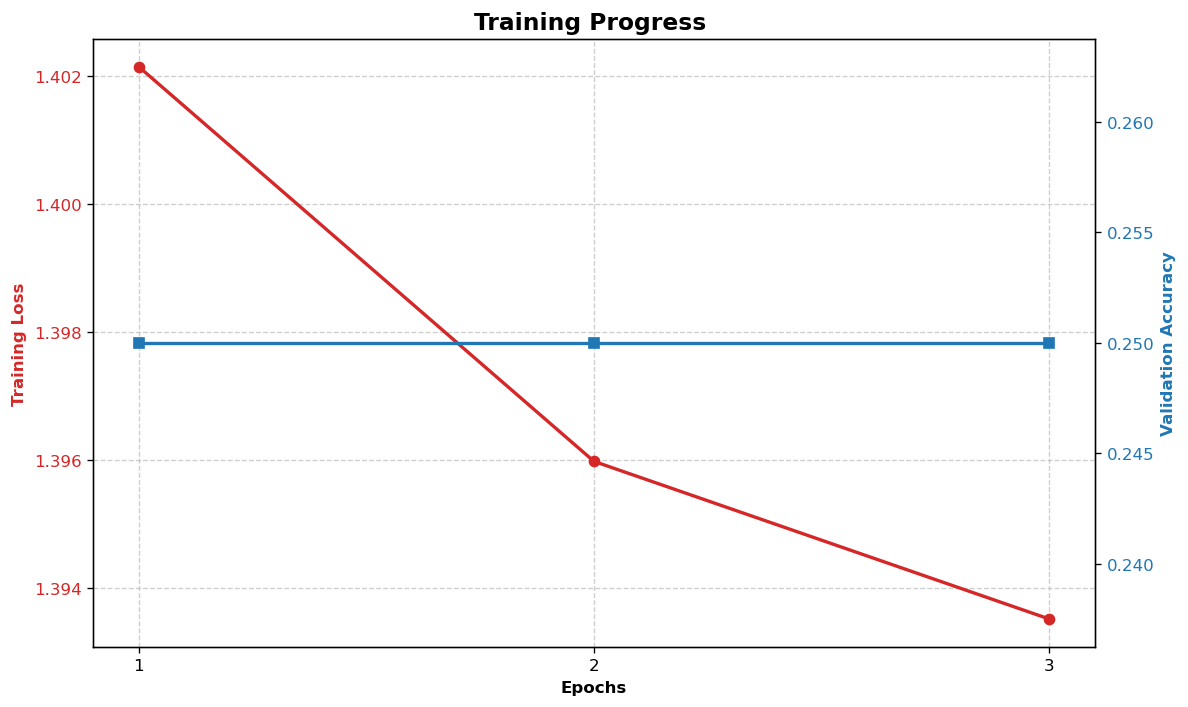

In [12]:
# Path to saved history file
history_file = "bert_scratch_history.json"

# Load the JSON data
with open(history_file, "r") as f:
    history_scratch = json.load(f)

# Plot the data
plot_metrics(history_scratch, title_suffix="")

### Discussion of Results (Task 2b)

**1. Validation Accuracy (The Flat Line at 25%)**
The validation accuracy remained perfectly flat at exactly 0.250 (25%) across all three epochs. Because this dataset contains exactly 4 distinct classes (World, Sports, Business, Sci/Tech), an accuracy of 25% indicates that the model is performing no better than random guessing. It has not yet extracted enough semantic meaning from the text to successfully distinguish between the categories on unseen data.

**2. Training Loss (The Downward Trend)**
The training loss started around 1.402 and decreased slightly to 1.394. Mathematically, the expected cross-entropy loss for a model making random guesses across 4 classes is the natural logarithm of 4 ($\ln(4)$), which is approximately 1.386. The initial loss aligns perfectly with this theoretical baseline. Crucially, the steady downward trend in the training loss confirms that the model's architecture, loss function, and optimizer are all functioning correctly. The model *is* learning, but at an incredibly slow pace.

**3. The "From Scratch" Bottleneck**
These results are entirely expected and highlight the difficulty of training large language models. The BERT architecture contains roughly 110 million parameters. Because we initialized the model completely from scratch with random weights, it currently has no understanding of English grammar, vocabulary, or context. Three epochs on 96,000 samples is simply not enough time or data for a model of this magnitude to learn the entire English language from scratch *and* simultaneously optimize for a specialized categorization task.

**Conclusion:**
This baseline proves that while the PyTorch training loop and architecture are solid, training a massive Transformer from scratch is highly inefficient in terms of data, compute time, and hardware limitations. To achieve practical accuracy on this task without requiring weeks of dedicated GPU training, leveraging pre-trained contextual representations is absolutely necessary.

## Task 2c: Fine-Tuning a Pre-Trained Model

In Task 2b, we saw that training a 110-million parameter model from scratch takes an immense amount of time and data because the model starts with zero knowledge of language. 

In this task, we will apply **Transfer Learning**. We will load a version of BERT (`bert-base-uncased`) that has already been pre-trained by Google on an enormous corpus of text (English Wikipedia and BookCorpus). Because this model already deeply understands English syntax, grammar, and semantics, we only need to "fine-tune" it to map its existing knowledge to our 4 specific news categories.

### Dataset setup

In [12]:
# Load the data
df = pd.read_csv('train.csv', header=0, names=['ClassIndex', 'Title', 'Description'])

# Combine Title and Description
df['FullText'] = df['Title'] + " - " + df['Description']

# Ensure the column is integer type, then shift labels to be 0-indexed 
df['ClassIndex'] = df['ClassIndex'].astype(int) - 1 

# Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    df['FullText'].values, 
    df['ClassIndex'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df['ClassIndex'].values
)

print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# Setup Tokenizer and DataLoaders
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = NewsDataset(X_train, y_train, tokenizer, max_len=128)
val_dataset = NewsDataset(X_val, y_val, tokenizer, max_len=128)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Training samples: 96000 | Validation samples: 24000


### Training  

In [14]:
# Initialize the Model WITH PRE-TRAINED WEIGHTS
print("Downloading and loading pre-trained BERT weights:")
model_pretrained = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)
model_pretrained = model_pretrained.to(device)

# Setup the Optimizer
# We use a slightly lower learning rate (2e-5) so we don't aggressively overwrite the pre-trained weights.
optimizer_pretrained = AdamW(model_pretrained.parameters(), lr=2e-5)

# Train the model
# train_loader, val_loader, and the training function are reused from 2b
print("\nStarting Fine-Tuning...")
history_pretrained = train_and_evaluate_tracked(
    model=model_pretrained, 
    train_loader=train_loader,   # Reusing from Task 2b
    val_loader=val_loader,       # Reusing from Task 2b
    optimizer=optimizer_pretrained, 
    epochs=3,
    save_prefix="bert_pretrained"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting Fine-Tuning...


NameError: name 'train_and_evaluate_tracked' is not defined

### Evaluation 

In [9]:
# Define paths
model_path = "bert_pretrained_epoch_3.pt" 
history_path = "bert_pretrained_history.json"

# Re-initialize the model architecture
print("Initializing BERT architecture...")
config = BertConfig.from_pretrained('bert-base-uncased', num_labels=4)
model_pretrained = BertForSequenceClassification(config)

# Load the saved weights
print(f"Loading weights from {model_path}...")
model_pretrained.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model_pretrained = model_pretrained.to(device)

# Load the training history
try:
    with open(history_path, "r") as f:
        history_pretrained = json.load(f)
    print("Model and history loaded successfully!")
except:
    print(f"Could not find {history_path}.")

Initializing BERT architecture...


Initializing BERT architecture...


NameError: name 'BertConfig' is not defined

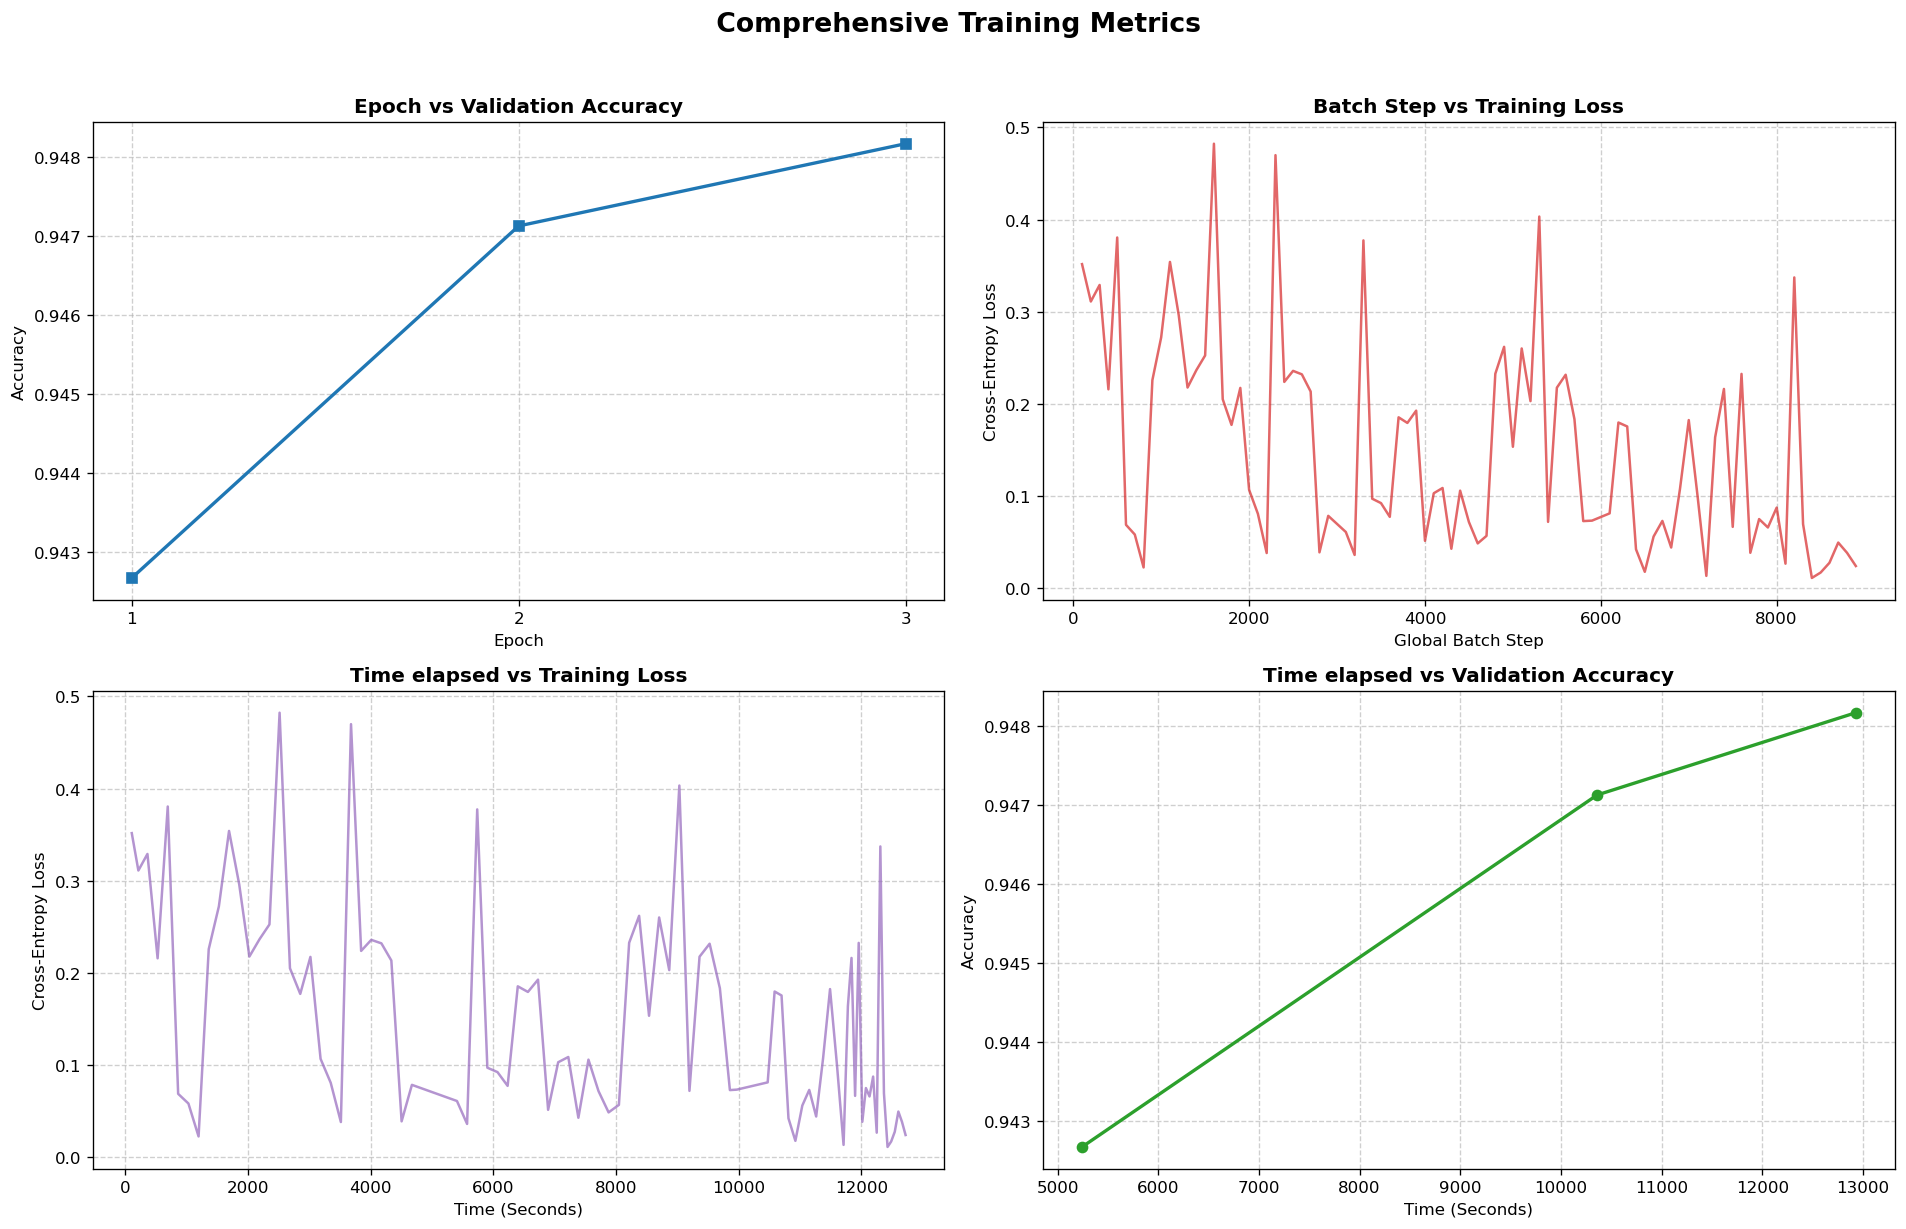

Running final evaluation pass on validation set...


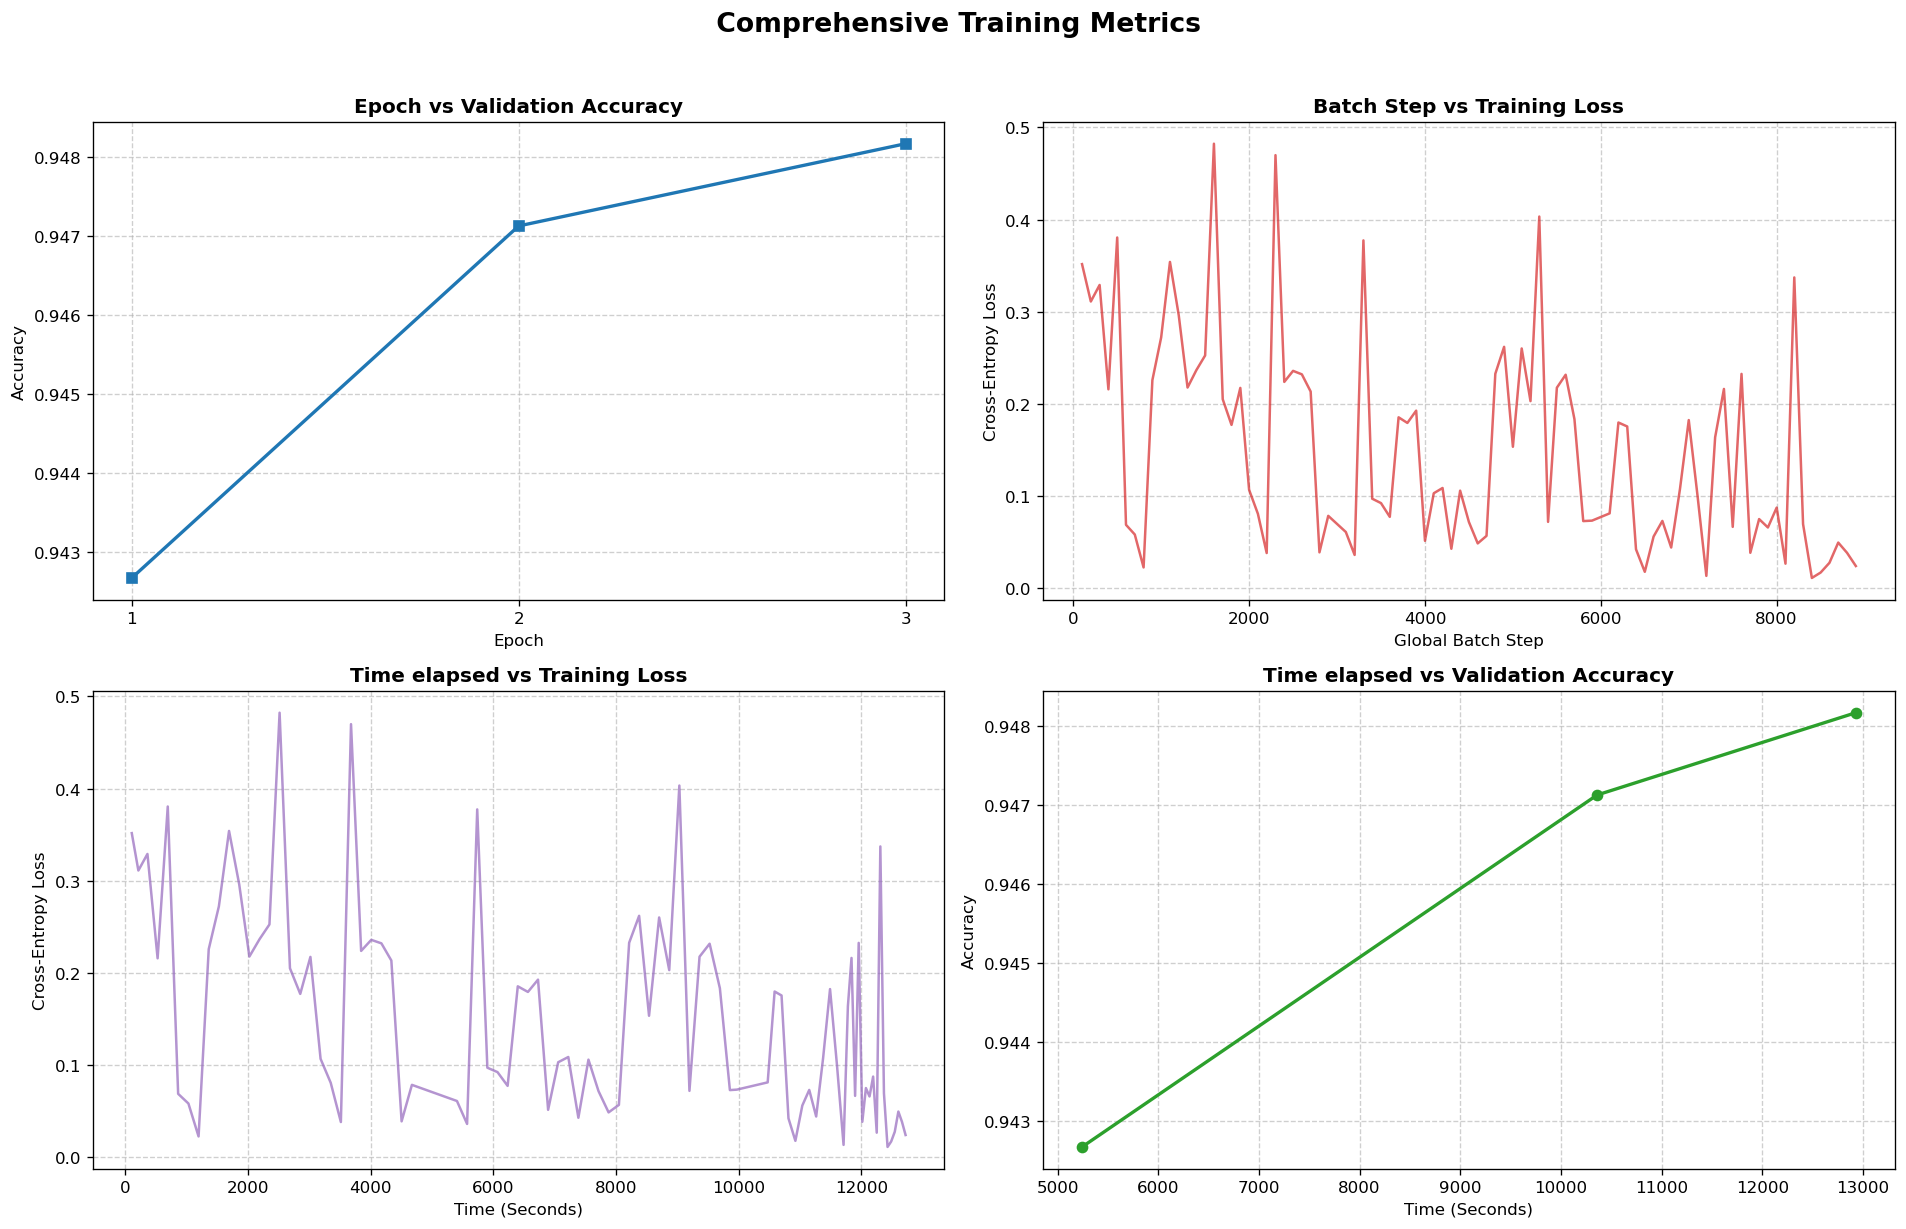

Running final evaluation pass on validation set...

=== Final Validation Metrics ===
Accuracy:  0.9482
Precision: 0.9483
Recall:    0.9482
F1-Score:  0.9482

              precision    recall  f1-score   support

       World       0.97      0.94      0.96      6000
      Sports       0.98      0.99      0.99      6000
    Business       0.92      0.92      0.92      6000
    Sci/Tech       0.92      0.94      0.93      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



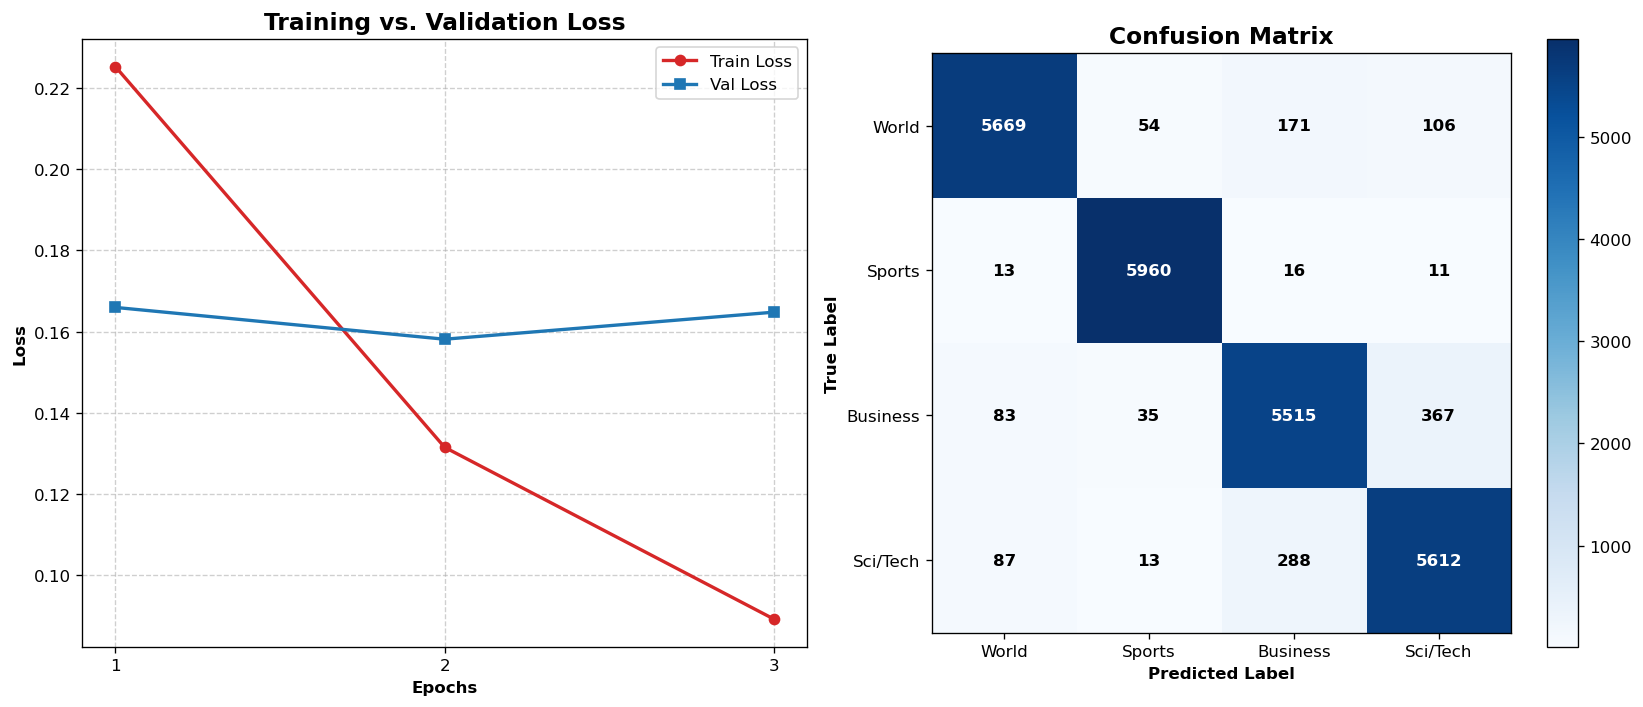

In [62]:
# Plot the data
plot_metrics_extended(history_pretrained)
metrics = evaluate_and_plot(model_pretrained, val_loader, history_dict=history_pretrained)

In [15]:
# Run the profiler on your fine-tuned pre-trained model
metrics_pretrained = profile_model_efficiency(
    model=model_pretrained, 
    val_loader=val_loader, 
    device=device, 
    model_name="BERT Base (Pre-trained Fine-Tuned)"
)

=== Profiling Report: BERT Base (Pre-trained Fine-Tuned) ===

[Architecture]
Total Parameters:     109,485,316
Trainable Parameters: 109,485,316
Model Memory Size:    417.66 MB

[Inference Speed]
Warming up GPU...
Total Time (Val Set): 682.24 seconds
Throughput:           35.18 samples / second
Average Latency:      28.43 ms / sample

[Performance]
Overall Accuracy:     0.9482
Weighted F1-Score:    0.9482

Detailed Classification Report:
              precision    recall  f1-score   support

       World       0.97      0.94      0.96      6000
      Sports       0.98      0.99      0.99      6000
    Business       0.92      0.92      0.92      6000
    Sci/Tech       0.92      0.94      0.93      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



In [61]:
training_metrics_pretrained = analyze_training_history(history_pretrained, "BERT Base (Pre-trained)")

=== Training History Analysis: BERT Base (Pre-trained) ===

[Speed & Duration]
Total Training Time: 215.49 minutes
Average Epoch Time:  4309.75 seconds
Average Batch Time:  1462.27 ms
Training Throughput: 0.68 batches / second

[Performance Highlights]
Best Val Accuracy:   0.9482 (Achieved in Epoch 3)
Best Val F1-Score:   0.9482 (Achieved in Epoch 3)
Lowest Val Loss:     0.1581 (Achieved in Epoch 2)


In [27]:
hardware_metrics = compare_hardware_speed(model_pretrained, val_loader, batches_to_test=10)

=== Hardware Inference Benchmark ===

Moving model to CPU...
Running inference on CPU...
  Total Time: 116.94s
  Throughput: 2.74 samples/sec
  Latency:    365.44 ms/sample

Moving model to CUDA...
Running inference on CUDA...
  Total Time: 5.83s
  Throughput: 54.85 samples/sec
  Latency:    18.23 ms/sample

>> GPU Speedup: The GPU is 20.0x faster than the CPU for inference.


In [39]:
# Example usage (assuming you defined 'tokenizer' earlier in the notebook):
errors_df = extract_failures(model_pretrained, val_loader, tokenizer)

# View the first 10 mistakes in your notebook:
print(errors_df.head(10))

Extracting misclassified samples...
Extraction complete! Found 1244 misclassified samples.
                                                Text True Label  \
0  nextel wants better fcc deal - nextel communic...   Sci/Tech   
1  intel puts its weight behind symbian - intel i...   Business   
2  stakes high for england - england will have a ...      World   
3  microsoft still wants eu settlement ( reuters ...   Business   
4  military snipers learn from competition ( ap )...     Sports   
5  un urged to ignore bush plea for human cloning...      World   
6  fcc denies states control of voip - providers ...   Business   
7  aerosols ' harm mother and baby ' - air freshe...      World   
8  the more the red sox and cubs talk about it, t...     Sports   
9  takenaka says tankan confirms japan # 39 ; s s...      World   

  Predicted Label Model Confidence  
0        Business            59.7%  
1        Sci/Tech            89.5%  
2          Sports            99.9%  
3        Sci/Tech      

### Evaluation 2.0

In [50]:
pred = predict_article_with_probability(
    model=model_pretrained,
    tokenizer=tokenizer,
    text="This Date in Baseball (AP),AP - 1934  #151; Daffy Dean of the St. Louis Cardinals pitched a no-hitter against the Brooklyn Dodgers for 3-0 victory in the second game of an Ebbets Field doubleheader. Daffy's brother, Dizzy, held Brooklyn hitless for eight innings in the opener and won 13-0.",
    device=device,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    max_length=128
)
print(pred)

{'predicted_index': 1, 'predicted_label': 'Sports', 'confidence': 0.9998526573181152, 'probabilities': {'World': 9.906497871270403e-05, 'Sports': 0.9998526573181152, 'Business': 2.417749783489853e-05, 'Sci/Tech': 2.407522151770536e-05}}


In [ ]:
ultimate = run_ultimate_analysis(
    model=model_pretrained,
    val_loader=val_loader,
    history=history_pretrained,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    model_name='bert_pretrained',
    force_validation_run=False,
    hardware_batches=50,
)

NameError: name 'model_pretrained' is not defined